# Yahoo! Finance

One of the most powerful financial data aggregators in the world is [yahoo!finance](https://finance.yahoo.com/). There is a free [API](https://pypi.org/project/yfinance/) that allows people all over the world to pull data about publicly traded companies. This is a reference notebook for basic functionality of the API and what it can do.

In [1]:
from datetime import datetime
import yfinance as yf
import pandas as pd
import numpy as np
import json

# Single Stock Analysis

Pulling a single stock and reading basic info using the Ticker object:

In [2]:
nvidia = yf.Ticker('NVDA')

In [3]:
nvidia.info['longBusinessSummary']

"NVIDIA Corporation provides graphics, and compute and networking solutions in the United States, Taiwan, China, and internationally. The company's Graphics segment offers GeForce GPUs for gaming and PCs, the GeForce NOW game streaming service and related infrastructure, and solutions for gaming platforms; Quadro/NVIDIA RTX GPUs for enterprise workstation graphics; vGPU software for cloud-based visual and virtual computing; automotive platforms for infotainment systems; and Omniverse software for building 3D designs and virtual worlds. Its Compute & Networking segment provides Data Center platforms and systems for AI, HPC, and accelerated computing; Mellanox networking and interconnect solutions; automotive AI Cockpit, autonomous driving development agreements, and autonomous vehicle solutions; cryptocurrency mining processors; Jetson for robotics and other embedded platforms; and NVIDIA AI Enterprise and other software. The company's products are used in gaming, professional visualiza

In [4]:
nvidia.info['regularMarketOpen']

496.43

In [5]:
nvidia.info['sharesOutstanding']

2470000128

In [6]:
nvidia.info['marketCap']

1223193526272

In [7]:
nvidia.major_holders

,0,1
0,4.04%,% of Shares Held by All Insider
1,68.57%,% of Shares Held by Institutions
2,71.46%,% of Float Held by Institutions
3,4803,Number of Institutions Holding Shares


In [8]:
nvidia.balance_sheet

,2023-01-31,2022-01-31,2021-01-31,2020-01-31
Treasury Shares Number,NaN,NaN,1380000000.0,1370057696.0
Ordinary Shares Number,2466136572.0,2506000000.0,2480000000.0,2567964768.0
Share Issued,2466136572.0,2506000000.0,3860000000.0,3938022464.0
Net Debt,10953000000.0,10946000000.0,6963000000.0,1991000000.0
Total Debt,11855000000.0,11687000000.0,7597000000.0,2552000000.0
...,...,...,...,...
Allowance For Doubtful Accounts Receivable,NaN,NaN,-21000000.0,NaN
Gross Accounts Receivable,NaN,NaN,2450000000.0,NaN
Cash Cash Equivalents And Short Term Investments,13296000000.0,21208000000.0,11561000000.0,10897000000.0
Other Short Term Investments,9907000000.0,19218000000.0,10714000000.0,1000000.0


In [9]:
nvidia.income_stmt

,2023-01-31,2022-01-31,2021-01-31,2020-01-31
Tax Effect Of Unusual Items,-284130000.0,0.0,0.0,0.0
Tax Rate For Calcs,0.21,0.019,0.017,0.059
Normalized EBITDA,7340000000.0,11351000000.0,5691000000.0,3403000000.0
Total Unusual Items,-1353000000.0,NaN,NaN,NaN
Total Unusual Items Excluding Goodwill,-1353000000.0,NaN,NaN,NaN
Net Income From Continuing Operation Net Minority Interest,4368000000.0,9752000000.0,4332000000.0,2796000000.0
Reconciled Depreciation,1544000000.0,1174000000.0,1098000000.0,381000000.0
Reconciled Cost Of Revenue,11618000000.0,9439000000.0,6279000000.0,4150000000.0
EBITDA,5987000000.0,11351000000.0,5691000000.0,3403000000.0
EBIT,4443000000.0,10177000000.0,4593000000.0,3022000000.0


In [10]:
nvidia.cashflow

,2023-01-31,2022-01-31,2021-01-31,2020-01-31
Free Cash Flow,3808000000.0,8132000000.0,4694000000.0,4272000000.0
Repurchase Of Capital Stock,-10039000000.0,NaN,0.0,0.0
Repayment Of Debt,0.0,-1000000000.0,0.0,0.0
Issuance Of Debt,0.0,4977000000.0,4968000000.0,NaN
Capital Expenditure,-1833000000.0,-976000000.0,-1128000000.0,-489000000.0
Interest Paid Supplemental Data,254000000.0,246000000.0,138000000.0,54000000.0
Income Tax Paid Supplemental Data,1404000000.0,396000000.0,249000000.0,176000000.0
End Cash Position,3389000000.0,1990000000.0,847000000.0,10896000000.0
Beginning Cash Position,1990000000.0,847000000.0,10896000000.0,782000000.0
Changes In Cash,1399000000.0,1143000000.0,-10049000000.0,10114000000.0


Set a date range to visually analyze an individual stock:

In [11]:
start_date = '2018-07-15'
end_date = '2023-12-26'

### Volatility

A statistical measure of the dispersion of returns for the Ticker. The higher the volatility, the riskier the stock.

In [12]:
nvidia = yf.download('NVDA', start=start_date, end=end_date)
nvidia['Log_Ret'] = np.log(nvidia['Close']/nvidia['Close'].shift(1))
nvidia['Volatility'] = nvidia['Log_Ret'].rolling(252).std() * np.sqrt(252)
nvidia.tail()

[*********************100%%**********************]  1 of 1 completed


,Open,High,Low,Close,Adj Close,Volume,Log_Ret,Volatility
Date,,,,,,,,
2023-12-18,494.000000,504.329987,491.500000,500.769989,500.769989,41258700,0.023989,0.480691
2023-12-19,494.239990,497.000000,488.950012,496.040009,496.040009,46444400,-0.009490,0.480126
2023-12-20,496.549988,499.989990,480.980011,481.109985,481.109985,39789400,-0.030561,0.480813
2023-12-21,488.109985,490.950012,484.190002,489.899994,489.899994,30042500,0.018105,0.480781
2023-12-22,491.950012,493.829987,484.670013,488.299988,488.299988,25213900,-0.003271,0.480374


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

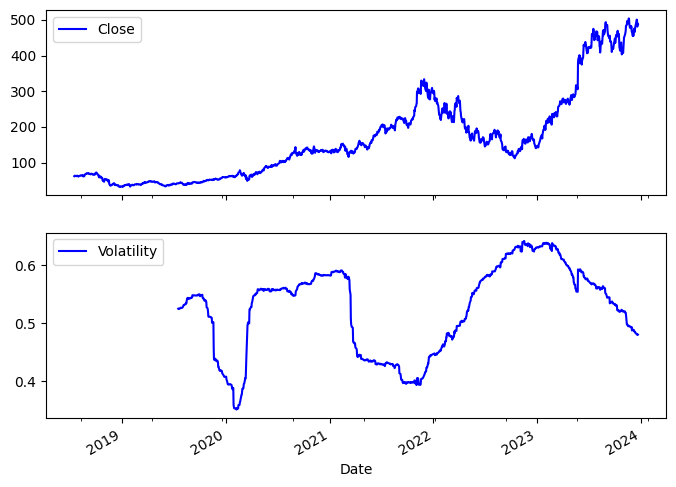

In [13]:
%matplotlib inline
nvidia[['Close', 'Volatility']].plot(subplots=True, color='blue', figsize=(8,6))

### Min, Mean, Max

Use a rolling window to plot the minimum, median, and maximum of the close price over a rolling window of time.

In [14]:
window = 20
data = pd.DataFrame(nvidia['Adj Close']).dropna()
data['min'] = data['Adj Close'].rolling(window=window).min()
data['max'] = data['Adj Close'].rolling(window=window).max()
data['mean'] = data['Adj Close'].rolling(window=window).mean()
data['std'] = data['Adj Close'].rolling(window=window).std()
data['median'] = data['Adj Close'].rolling(window=window).median()
data.dropna().head()

,Adj Close,min,max,mean,std,median
Date,,,,,,
2018-08-10,63.105026,60.464821,64.004112,62.317306,0.957747,62.400404
2018-08-13,63.434441,60.464821,64.004112,62.415386,0.967112,62.420221
2018-08-14,64.749588,60.464821,64.749588,62.511235,1.096921,62.420221
2018-08-15,64.167549,60.464821,64.749588,62.602627,1.156410,62.430122
2018-08-16,63.761368,60.464821,64.749588,62.669623,1.183849,62.677797


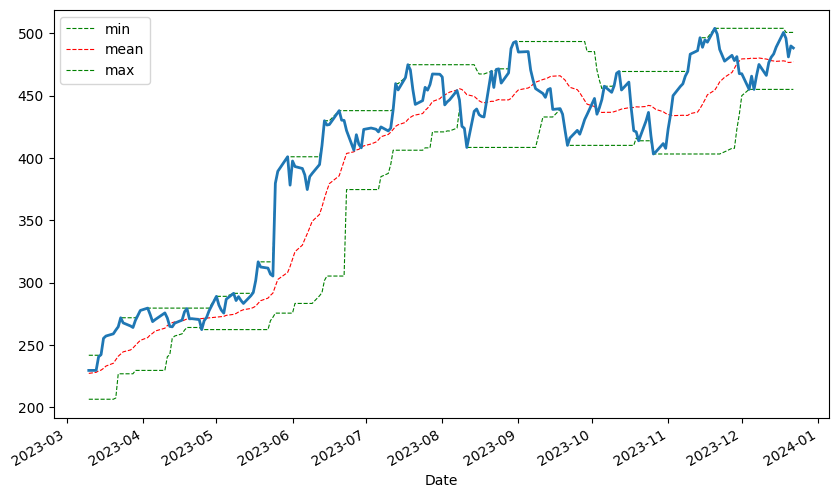

In [15]:
ax = data[['min', 'mean', 'max']].iloc[-200:].plot(
    figsize = (10,6), style = ['g--', 'r--', 'g--'], lw=0.8
)
data['Adj Close'].iloc[-200:].plot(ax=ax, lw=2.0);

### Simple Moving Averages

A moving average represents the sum of the closing prices over a specific number of periods. If a moving average is rising, it can signal that the stock is in an uptrend. If a moving average is falling, it can signal that the stock is in a downtrend.

In [16]:
data['SMA1'] = data['Adj Close'].rolling(window=42).mean()
data['SMA2'] = data['Adj Close'].rolling(window=252).mean()
data[['Adj Close', 'SMA1', 'SMA2']].tail()

,Adj Close,SMA1,SMA2
Date,,,
2023-12-18,500.769989,462.104569,353.202477
2023-12-19,496.040009,463.891879,354.513602
2023-12-20,481.109985,465.493697,355.778054
2023-12-21,489.899994,466.926740,357.084091
2023-12-22,488.299988,468.157891,358.367279


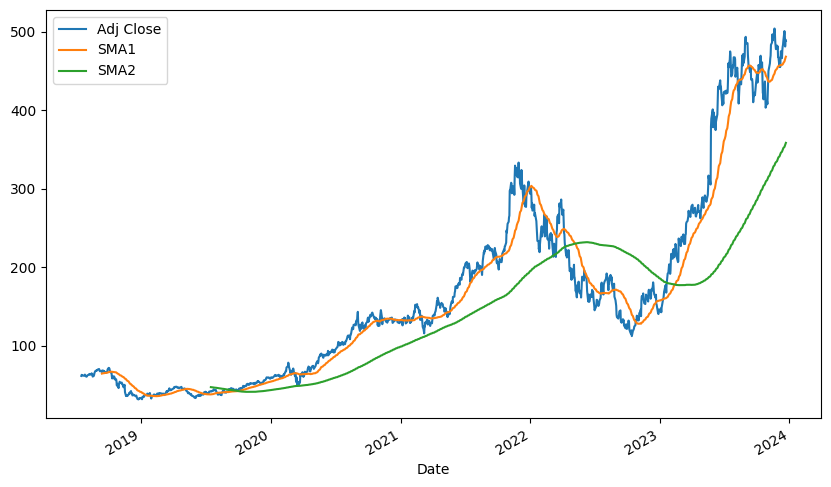

In [17]:
data[['Adj Close', 'SMA1', 'SMA2']].plot(figsize=(10,6));

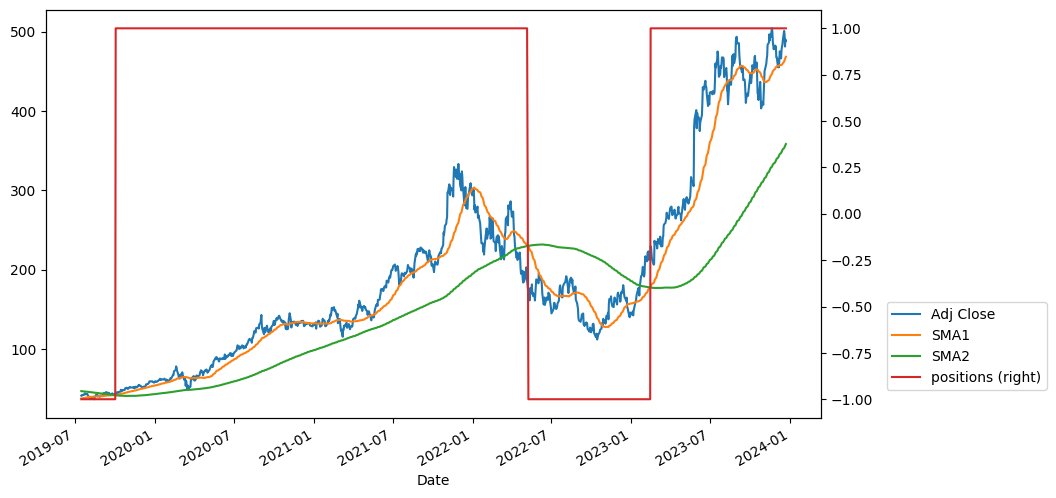

In [18]:
data.dropna(inplace=True)
data['positions'] = np.where(data['SMA1'] > data['SMA2'], 1, -1)
ax = data[['Adj Close', 'SMA1', 'SMA2', 'positions']].plot(figsize=(10,6), secondary_y='positions')
ax.get_legend().set_bbox_to_anchor((1.3, 0.3))

## Multi-Stock Analysis

Pulling data from Yahoo! a dictionary of stock tickers that can be referenced for comparative analysis across multiple stocks.

In [19]:
f = open('_stocks.json')
instruments = json.load(f)
f.close()

## Simple Analysis
We can select a list of stocks to analyze and then determine the date range for which we want to analyze historical data. I will look at a few selections over the past decade, including a few key indexes for reference.

In [20]:
stocks = ['NXPI', 'TSLA', 'PLUG', '^IXIC', 'SPY', 'GLD']

In [21]:
start_date = datetime(2013,1,1)
end_date = datetime(2023,1,1)

This pulls the data from yFinance and then creates a dataframe of all the stock prices at close for every day in the selected date range. We'll drop the days where there were no trading. 

In [22]:
tick_data = yf.download(stocks, start=start_date, end=end_date)
eod = tick_data['Adj Close']
for symbol in eod.columns:
    print('{:8s} | {}'.format(symbol, instruments[symbol]))

[*********************100%%**********************]  6 of 6 completed
GLD      | SPDR Gold Trust
NXPI     | NXP Semiconductors
PLUG     | Plug Power
SPY      | SPDR S&P 500 ETF Trust
TSLA     | Tesla Stock
^IXIC    | Nasdaq Composite


In [23]:
eod = eod.dropna()
eod.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2518 entries, 2013-01-02 to 2022-12-30
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GLD     2518 non-null   float64
 1   NXPI    2518 non-null   float64
 2   PLUG    2518 non-null   float64
 3   SPY     2518 non-null   float64
 4   TSLA    2518 non-null   float64
 5   ^IXIC   2518 non-null   float64
dtypes: float64(6)
memory usage: 137.7 KB


In [24]:
eod.head()

,GLD,NXPI,PLUG,SPY,TSLA,^IXIC
Date,,,,,,
2013-01-02,163.169998,25.623611,0.50,119.491989,2.357333,3112.260010
2013-01-03,161.199997,25.494713,0.51,119.222069,2.318000,3100.570068
2013-01-04,160.440002,25.172461,0.53,119.745644,2.293333,3101.659912
2013-01-07,159.429993,24.988314,0.53,119.418427,2.289333,3098.810059
2013-01-08,160.559998,24.445089,0.54,119.074768,2.245333,3091.810059


Here I'm showing the normalized prices of each instrument from my selection.

<Axes: xlabel='Date'>

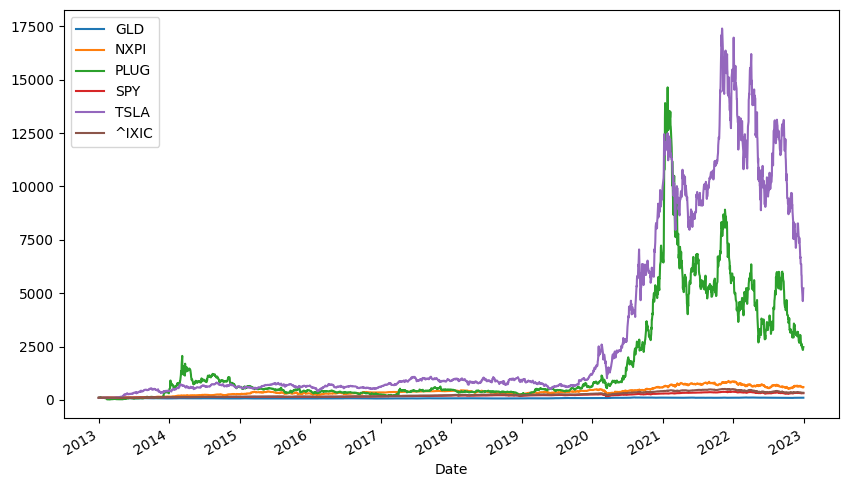

In [25]:
(eod / eod.iloc[0] * 100).plot(figsize=(10, 6))

Now we take the data and find log returns for each stock. Using log returns instead of simple returns for time series analysis helps us reduce variation and create more accurate predictive models on a stock.

In [26]:
log_returns = np.log(eod / eod.shift(1))
log_returns.head()

,GLD,NXPI,PLUG,SPY,TSLA,^IXIC
Date,,,,,,
2013-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2013-01-03,-0.012147,-0.005043,0.019803,-0.002261,-0.016826,-0.003763
2013-01-04,-0.004726,-0.012721,0.038466,0.004382,-0.010699,0.000351
2013-01-07,-0.006315,-0.007342,0.000000,-0.002736,-0.001746,-0.000919
2013-01-08,0.007063,-0.021979,0.018692,-0.002882,-0.019407,-0.002261


From our log returns, we can plot the data and look at some simple, informative statistics of the distribution.

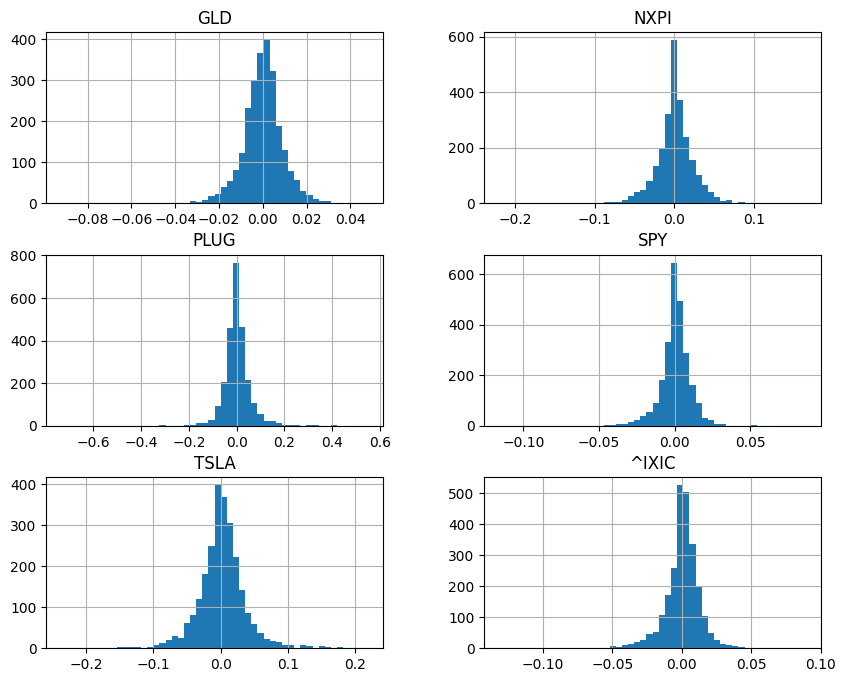

In [27]:
log_returns.hist(bins=50, figsize=(10, 8));

In [28]:
for stock in stocks:
    log_data = pd.DataFrame(log_returns[stock].dropna())
    print('\nResults for {}'.format(instruments[stock]))
    print(30 * '-')
    print(log_data.describe())
    print("skew\t", log_data.skew().values[0])
    print("kurtosis ", log_data.kurt().values[0])


Results for NXP Semiconductors
------------------------------
              NXPI
count  2517.000000
mean      0.000715
std       0.025014
min      -0.219520
25%      -0.010204
50%       0.000691
75%       0.012229
max       0.164716
skew	 -0.3437339053222575
kurtosis  9.308173681453273

Results for Tesla Stock
------------------------------
              TSLA
count  2517.000000
mean      0.001572
std       0.035858
min      -0.236518
25%      -0.015065
50%       0.001300
75%       0.018793
max       0.218292
skew	 0.005997893852257731
kurtosis  5.031366160604798

Results for Plug Power
------------------------------
              PLUG
count  2517.000000
mean      0.001275
std       0.060556
min      -0.733969
25%      -0.025318
50%       0.000000
75%       0.023531
max       0.548566
skew	 0.17330077675499006
kurtosis  20.495533696932267

Results for Nasdaq Composite
------------------------------
             ^IXIC
count  2517.000000
mean      0.000482
std       0.013053
min      -0.